Running 15-Fold CV for AutoGluon (Fast Mode)...


2026-08-17 14:34:46,176	INFO worker.py:2015 -- Started a local Ray instance. View the dashboard at http://127.0.0.1:8265 
	No models were trained successfully during fit(). Inspect the log output or increase verbosity to determine why no models were fit. Alternatively, set `raise_on_no_models_fitted` to False during the fit call.
	No models were trained successfully during fit(). Inspect the log output or increase verbosity to determine why no models were fit. Alternatively, set `raise_on_no_models_fitted` to False during the fit call.
	No models were trained successfully during fit(). Inspect the log output or increase verbosity to determine why no models were fit. Alternatively, set `raise_on_no_models_fitted` to False during the fit call.
	No models were trained successfully during fit(). Inspect the log output or increase verbosity to determine why no models were fit. Alternatively, set `raise_on_no_models_fitted` to False during the fit call.
	No models were trained successfully d

AutoGluon Metrics -> ACC: 0.938±0.019 | AUC: 0.982±0.017 | F1: 0.870±0.043
Generating Out-Of-Fold Predictions...


	No models were trained successfully during fit(). Inspect the log output or increase verbosity to determine why no models were fit. Alternatively, set `raise_on_no_models_fitted` to False during the fit call.
	No models were trained successfully during fit(). Inspect the log output or increase verbosity to determine why no models were fit. Alternatively, set `raise_on_no_models_fitted` to False during the fit call.
	No models were trained successfully during fit(). Inspect the log output or increase verbosity to determine why no models were fit. Alternatively, set `raise_on_no_models_fitted` to False during the fit call.
	No models were trained successfully during fit(). Inspect the log output or increase verbosity to determine why no models were fit. Alternatively, set `raise_on_no_models_fitted` to False during the fit call.
	No models were trained successfully during fit(). Inspect the log output or increase verbosity to determine why no models were fit. Alternatively, set `raise_o

Training final AutoGluon model on full dataset...


Leaderboard on holdout data (DyStack):
                          model  score_holdout  score_val eval_metric  pred_time_test  pred_time_val  fit_time  pred_time_test_marginal  pred_time_val_marginal  fit_time_marginal  stack_level  can_infer  fit_order
0        LightGBMXT_BAG_L1_FULL       1.000000   0.982975     roc_auc        0.074458            NaN  0.443180                 0.074458                     NaN           0.443180            1       True          1
1      WeightedEnsemble_L2_FULL       1.000000   0.983875     roc_auc        0.346622            NaN  2.180079                 0.040708                     NaN           0.055540            2       True          4
2          LightGBM_BAG_L2_FULL       1.000000   0.982075     roc_auc        0.436131            NaN  2.451545                 0.130217                     NaN           0.327006            2       True          6
3        LightGBMXT_BAG_L2_FULL       1.000000   0.984625     roc_auc        0.450198            NaN  2.4

[1000]	valid_set's binary_logloss: 0.00145091
[2000]	valid_set's binary_logloss: 0.00108777


	0.9914	 = Validation score   (roc_auc)
	6.28s	 = Training   runtime
	0.07s	 = Validation runtime
Fitting model: LightGBM_BAG_L1 ... Training model for up to 64.77s of the 64.77s of remaining time.
	Fitting 8 child models (S1F1 - S1F8) | Fitting with SequentialLocalFoldFittingStrategy (sequential: cpus=1, gpus=0)
	0.9853	 = Validation score   (roc_auc)
	7.19s	 = Training   runtime
	0.08s	 = Validation runtime
Fitting model: RandomForestGini_BAG_L1 ... Training model for up to 57.31s of the 57.31s of remaining time.
	Fitting 1 model on all data (use_child_oof=True) | Fitting with cpus=1, gpus=0
	0.9821	 = Validation score   (roc_auc)
	1.76s	 = Training   runtime
	0.22s	 = Validation runtime
Fitting model: RandomForestEntr_BAG_L1 ... Training model for up to 55.18s of the 55.18s of remaining time.
	Fitting 1 model on all data (use_child_oof=True) | Fitting with cpus=1, gpus=0
	0.9787	 = Validation score   (roc_auc)
	1.78s	 = Training   runtime
	0.27s	 = Validation runtime
Fitting model: 

Calculating AutoGluon Feature Importances...


	99.1s	= Expected runtime (19.82s per shuffle set)
	4.06s	= Actual runtime (Completed 5 of 5 shuffle sets)


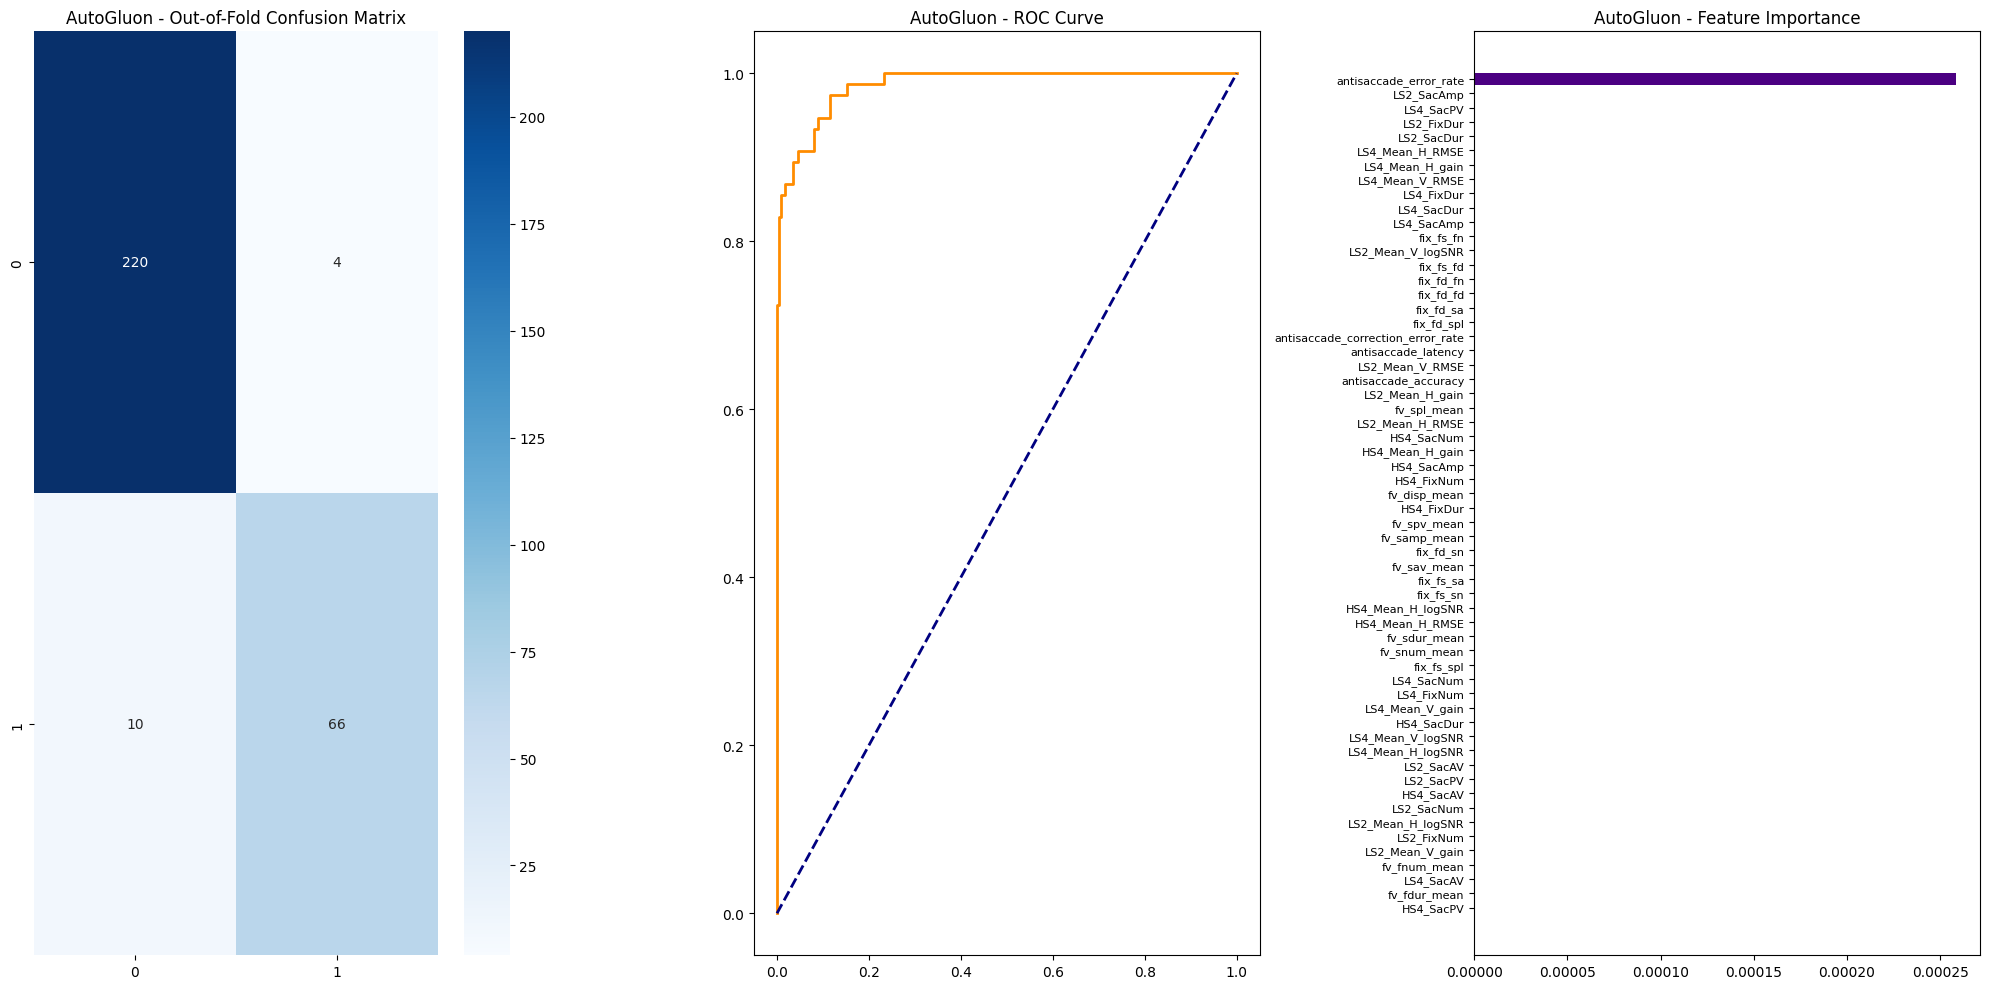

In [1]:
import uuid
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import logging
from sklearn.model_selection import StratifiedKFold, RepeatedStratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, roc_curve, confusion_matrix
from autogluon.tabular import TabularPredictor

# Suppress warnings to keep your Git output clean
warnings.filterwarnings('ignore')
pd.options.mode.chained_assignment = None
logging.getLogger("autogluon").setLevel(logging.ERROR)
logging.getLogger("ray").setLevel(logging.ERROR)

def run_fast_autogluon_pipeline():
    # 1. Load Data
    df = pd.read_csv('synthetic_eye_tracking_HC_SZ_300.csv')
    X = df.drop(columns=['subject_id', 'label', 'calibration_error'])
    y = LabelEncoder().fit_transform(df['label'])
    
    # 2. Repeated Stratified CV (For Paper Metrics)
    rskf = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=42)
    accs, aucs, f1s = [], [], []
    
    print("Running 15-Fold CV for AutoGluon (Fast Mode)...")
    for train_idx, val_idx in rskf.split(X, y):
        X_train, X_val = X.iloc[train_idx].copy(), X.iloc[val_idx].copy()
        X_train['target'] = y[train_idx]
        
        unique_path = f"autogluon_cache/fold_{uuid.uuid4().hex}"
        
        predictor = TabularPredictor(label='target', eval_metric='roc_auc', path=unique_path, verbosity=0).fit(
            train_data=X_train, 
            presets='good_quality',  # Faster preset
            excluded_model_types=['NN_TORCH', 'FASTAI'],  # Skip slow neural networks
            time_limit=60,  
            ag_args_ensemble={'fold_fitting_strategy': 'sequential_local'},
            num_cpus=1       
        )
        
        preds = predictor.predict(X_val).values
        probs = predictor.predict_proba(X_val).iloc[:, 1].values
        
        accs.append(accuracy_score(y[val_idx], preds))
        aucs.append(roc_auc_score(y[val_idx], probs))
        f1s.append(f1_score(y[val_idx], preds))
    
    print(f"AutoGluon Metrics -> ACC: {np.mean(accs):.3f}±{np.std(accs):.3f} | AUC: {np.mean(aucs):.3f}±{np.std(aucs):.3f} | F1: {np.mean(f1s):.3f}±{np.std(f1s):.3f}")
    
    # 3. Out-Of-Fold Predictions (For CSV, CM, ROC)
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    oof_preds, oof_probs = np.zeros(len(y)), np.zeros(len(y))
    
    print("Generating Out-Of-Fold Predictions...")
    for train_idx, val_idx in skf.split(X, y):
        X_train, X_val = X.iloc[train_idx].copy(), X.iloc[val_idx].copy()
        X_train['target'] = y[train_idx]
        
        unique_path = f"autogluon_cache/oof_{uuid.uuid4().hex}"
        
        predictor = TabularPredictor(label='target', eval_metric='roc_auc', path=unique_path, verbosity=0).fit(
            train_data=X_train, 
            presets='good_quality', 
            excluded_model_types=['NN_TORCH', 'FASTAI'],
            time_limit=60,  
            ag_args_ensemble={'fold_fitting_strategy': 'sequential_local'},
            num_cpus=1
        )
        oof_preds[val_idx] = predictor.predict(X_val).values
        oof_probs[val_idx] = predictor.predict_proba(X_val).iloc[:, 1].values
    
    # Save OOF Predictions
    pd.DataFrame({
        'subject_id': df['subject_id'], 'actual_label': y, 
        'predicted_label': oof_preds, 'predicted_prob': oof_probs, 
        'calibration_error': df['calibration_error']
    }).to_csv('predictions_autogluon.csv', index=False)
    
    # 4. Final Model on FULL Data (For Save & Feature Importance)
    print("Training final AutoGluon model on full dataset...")
    full_data = X.copy()
    full_data['target'] = y
    
    final_predictor = TabularPredictor(label='target', eval_metric='roc_auc', path='model_autogluon').fit(
        train_data=full_data, 
        presets='good_quality',
        excluded_model_types=['NN_TORCH', 'FASTAI'],
        time_limit=120,  
        ag_args_ensemble={'fold_fitting_strategy': 'sequential_local'},
        num_cpus=1
    )
    
    # 5. Plotting
    fig, axes = plt.subplots(1, 3, figsize=(20, 10))
    sns.heatmap(confusion_matrix(y, oof_preds), annot=True, fmt='d', cmap='Blues', ax=axes[0])
    axes[0].set_title("AutoGluon - Out-of-Fold Confusion Matrix")
    
    fpr, tpr, _ = roc_curve(y, oof_probs)
    axes[1].plot(fpr, tpr, color='darkorange', lw=2)
    axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    axes[1].set_title("AutoGluon - ROC Curve")
    
    print("Calculating AutoGluon Feature Importances...")
    fi_df = final_predictor.feature_importance(full_data)
    importances = fi_df['importance'].values[::-1]
    fi_names = fi_df.index.tolist()[::-1]
    
    axes[2].barh(range(len(importances)), importances, color='indigo')
    axes[2].set_yticks(range(len(importances)))
    axes[2].set_yticklabels(fi_names, fontsize=8)
    axes[2].set_title("AutoGluon - Feature Importance")
    plt.tight_layout()
    plt.show()

if __name__ == '__main__':
    run_fast_autogluon_pipeline()

Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.6.1
Python Version:     3.11.4
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.26200
CPU Count:          12
Pytorch Version:    2.10.0+cpu
CUDA Version:       CUDA is not available
Memory Avail:       3.07 GB / 15.73 GB (19.5%)
Disk Space Avail:   18.17 GB / 232.13 GB (7.8%)
Presets specified: ['good_quality']
Using hyperparameters preset: hyperparameters='light'
Setting dynamic_stacking from 'auto' to True. Reason: Enable dynamic_stacking when use_bag_holdout is disabled. (use_bag_holdout=False)
Stack configuration (auto_stack=True): num_stack_levels=1, num_bag_folds=8, num_bag_sets=1
Note: `save_bag_folds=False`! This will greatly reduce peak disk usage during fit (by ~8x), but runs the risk of an out-of-memory error during model refit if memory is small relative to the data size.
	You can avoid this risk by setting `save_bag_folds=True`.
DyStack is

Training final AutoGluon model on 80% split for Feature Importance...


Leaderboard on holdout data (DyStack):
                           model  score_holdout  score_val eval_metric  pred_time_test  pred_time_val   fit_time  pred_time_test_marginal  pred_time_val_marginal  fit_time_marginal  stack_level  can_infer  fit_order
0      LightGBMLarge_BAG_L2_FULL       1.000000   0.961565     roc_auc        0.840632            NaN  69.246019                 0.113933                     NaN           0.584153            2       True         19
1   RandomForestGini_BAG_L1_FULL       0.992857   0.978803     roc_auc        0.196088       0.265393   1.986005                 0.196088                0.265393           1.986005            1       True          3
2     ExtraTreesGini_BAG_L1_FULL       0.992857   0.975949     roc_auc        0.198146       0.198845   1.520108                 0.198146                0.198845           1.520108            1       True          6
3           LightGBM_BAG_L2_FULL       0.992857   0.970999     roc_auc        0.832695           

[1000]	valid_set's binary_logloss: 0.00068254


	0.9598	 = Validation score   (roc_auc)
	21.34s	 = Training   runtime
	0.1s	 = Validation runtime
Fitting model: WeightedEnsemble_L2 ...
	Fitting 1 model on all data | Fitting with cpus=1, gpus=0, mem=0.0/3.8 GB
	Ensemble Weights: {'CatBoost_BAG_L1': 0.522, 'LightGBMXT_BAG_L1': 0.348, 'ExtraTreesEntr_BAG_L1': 0.13}
	0.9847	 = Validation score   (roc_auc)
	0.2s	 = Training   runtime
	0.0s	 = Validation runtime
Excluded models: ['FASTAI', 'NN_TORCH'] (Specified by `excluded_model_types`)
Fitting 9 L2 models, fit_strategy="sequential" ...
Fitting model: LightGBMXT_BAG_L2 ...
	Fitting 8 child models (S1F1 - S1F8) | Fitting with SequentialLocalFoldFittingStrategy (sequential: cpus=1, gpus=0)
	0.9843	 = Validation score   (roc_auc)
	6.28s	 = Training   runtime
	0.11s	 = Validation runtime
Fitting model: LightGBM_BAG_L2 ...
	Fitting 8 child models (S1F1 - S1F8) | Fitting with SequentialLocalFoldFittingStrategy (sequential: cpus=1, gpus=0)
	0.967	 = Validation score   (roc_auc)
	8.04s	 = Train

Calculating AutoGluon Feature Importances on Unseen Data...


	640.68s	= Expected runtime (128.14s per shuffle set)
	12.96s	= Actual runtime (Completed 5 of 5 shuffle sets)


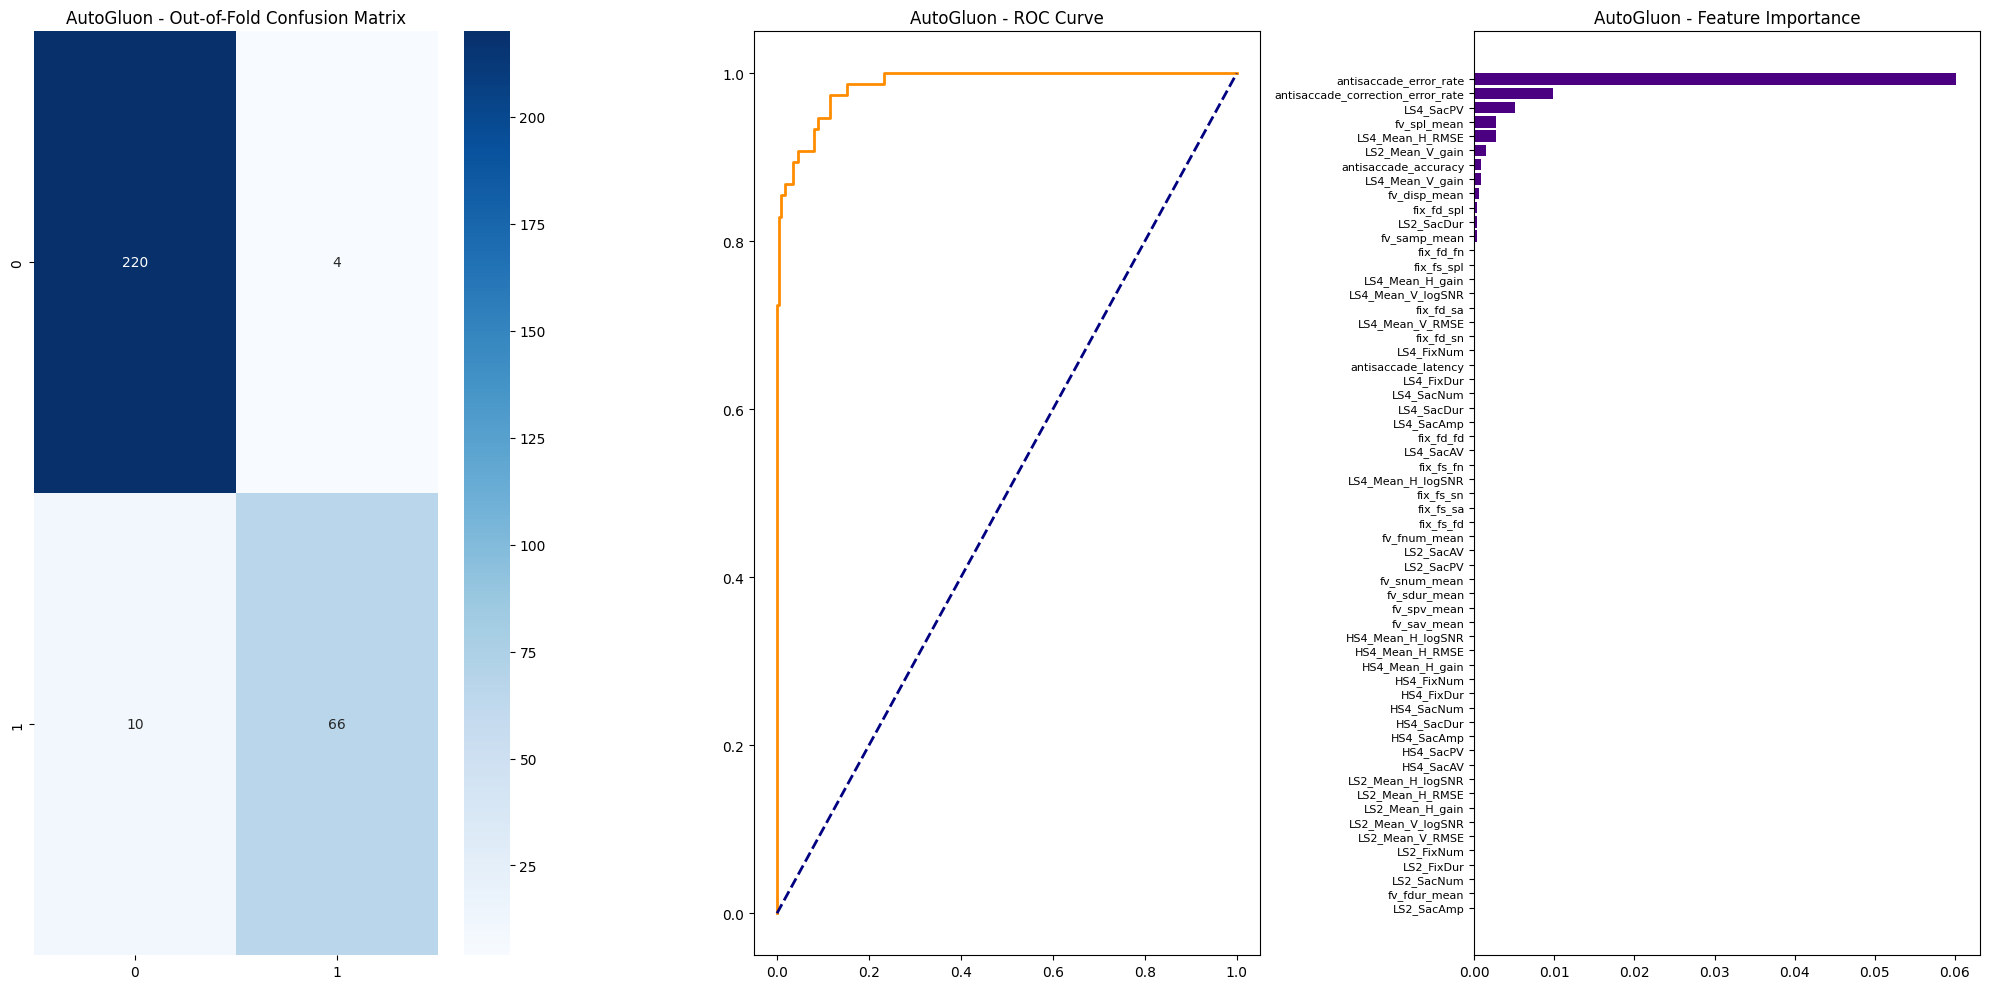

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import roc_curve, confusion_matrix
from autogluon.tabular import TabularPredictor
import warnings
warnings.filterwarnings('ignore')

# 1. Reload the dataset to recreate X and y
df = pd.read_csv('synthetic_eye_tracking_HC_SZ_300.csv')
X = df.drop(columns=['subject_id', 'label', 'calibration_error'])
y = LabelEncoder().fit_transform(df['label'])

# 2. Reload the predictions we saved earlier for the Confusion Matrix & ROC Curve
oof_df = pd.read_csv('predictions_autogluon.csv')
oof_preds = oof_df['predicted_label'].values
oof_probs = oof_df['predicted_prob'].values

# 3. Final Model (For Save & Feature Importance)
print("Training final AutoGluon model on 80% split for Feature Importance...")

X_train_fin, X_test_fin, y_train_fin, y_test_fin = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

ag_train_fin = X_train_fin.copy()
ag_train_fin['target'] = y_train_fin

ag_test_fin = X_test_fin.copy()
ag_test_fin['target'] = y_test_fin

# Train on the 80% split (using a slightly different path name to avoid overwriting)
final_predictor = TabularPredictor(label='target', eval_metric='roc_auc', path='model_autogluon_feature_imp').fit(
    train_data=ag_train_fin, 
    presets='good_quality',
    excluded_model_types=['NN_TORCH', 'FASTAI'],
    time_limit=None,  
    ag_args_ensemble={'fold_fitting_strategy': 'sequential_local'},
    num_cpus=1
)

# 4. Plotting
fig, axes = plt.subplots(1, 3, figsize=(20, 10))
sns.heatmap(confusion_matrix(y, oof_preds), annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title("AutoGluon - Out-of-Fold Confusion Matrix")

fpr, tpr, _ = roc_curve(y, oof_probs)
axes[1].plot(fpr, tpr, color='darkorange', lw=2)
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1].set_title("AutoGluon - ROC Curve")

print("Calculating AutoGluon Feature Importances on Unseen Data...")
fi_df = final_predictor.feature_importance(ag_test_fin)
importances = fi_df['importance'].values[::-1]
fi_names = fi_df.index.tolist()[::-1]

axes[2].barh(range(len(importances)), importances, color='indigo')
axes[2].set_yticks(range(len(importances)))
axes[2].set_yticklabels(fi_names, fontsize=8)
axes[2].set_title("AutoGluon - Feature Importance")
plt.tight_layout()
plt.show()